# Apuntes Spark: Spark y la libreria MLlib en Python

## Recordando MLlib

**Es una herramienta habilitada para realizar machine learning sobre Spark**

> Dispone de implementaciones para aprendizaje estadistico, desde algoritmos de regresion o clasificacion, o algoritmos de clustering, recomednacion y deep learning

Ofrece todos los componentes necesarios para hacer a escala big data:

- 1º el preprocesado y preparacion de los datos
- 2º definicion de modelos y entrenamiento
- 3º validacion y ejecucion de modelos


Esta libreria es idonea para realizar calculos que necesiten realizar una **regresion para estimar un valor no medido a partir de ciertas variables explicativas observadas**

> Es decir, hacer una estimacion de comportamiento en base a unos datos que expliquen la realidad y permitan volver a reproducirla con otros datos distintos


## Consideraciones iniciales

Recuerda que para poder hacer uso de la libreria es necesario importar algunas librerias concretas tal y como son:

> ***import pyspark.sql.functions as F***
>
> ***from pyspark.sql.functions import col***

## 1.0 Medir los coeficientes de correlacion de variables, como entenderlos y ajustarlos

El inicio de este proceso es la comprobacion de **relacion entre las variables explicativas que dan explicacion al comportamiento que se pretende estimar**

Para ello haremos uso de la funcion ***F.corr()*** que determina el coeficiente de correlacion entre 2 columnas

> Es redomendable añadir un ***F.round()*** que recoja el calculo para que el resultado este simplifcado en 2 decimales.

Ahora te explicamos como se puede utilizar en fuincion de lo que quieras medir:


### *Correlacion global:* Si quieres medir el comportamiento de 2 variables ***en toda la tabla de datos (sin dividir en grupos)***, puedes expresarlo de estas maneras:

Esto es por ejemplo **explicar si una variable tiene dependencia de otra, sin ninguna presuncion previa** (*¿Si sube esto, esto otro sube o baja?*)

> ***nombre variable.select(F.round(F.corr("nombre columna 1", "nombre columna 2"), "nº de variables a correlacionar"))***
>
> ***nombre variable.agg(F.round(F.corr("nombre columna 1", "nombre columna 2"), "nº de variables a correlacionar"))***

### *Correlacion local:* Si quieres medir el comportamiento de 2 variables ***en base a un segmento (sin dividir en grupos)***, puedes expresarlo de estas maneras:

Esto es por ejemplo  **entender la dependencia de 2 variable en base a otra variable** (*De este grupo o categoria de datos ¿Esta variable y esta otra se influyen o modifican?*)

> ***nombre variable.groupBy("columna por la que se hace el segmento").agg(F.round(F.corr("nombre columna 1", "nombre columna 2"), "nº de variables a correlacionar").alias("nombre columna correlacion"))***


## ¿Como entender los coeficientes de correlaciones?

**Los coeficientes de correlaciones son un valor estadistico que explica la dependencia entre 2 conjuntos de valores**

Hay que tener en cuenta que el coeficiente de correlación puede variar entre -1 y 1, y sus resultados nos dicen:

- Un coeficiente de correlación **próximo a 1 nos indica que existe una fuerte correlación positiva** (si la variable explicativa aumenta, también lo hace proporcionalmente la variable dependiente)
- **Un valor igual a 1 nos dice que hay una correlación perfecta.**
- Y al contrario, si el coeficiente de correlación **está próximo a -1, nos indica que existe una fuerte correlación negativa** (si la variable explicativa crece, la variable dependiente disminuye proporcionalmente).
- **Si el coeficiente de correlación vale cero, no podemos establecer una relación lineal (proporcional) entre las variables** (pero podría haber una relación no lineal).

## ¿Que sucede si medimos en 2 grupos sus coeficientes de correlacion?

La asimetria nos va a decir **que es necesario tener en cuenta la agrupacion que hacemos ya que modificar la relacion entre las 2 variables y  nos obligara a *redistribuir* los resultados a algo mas simetrico**

- Una simetria indicaria que **ambos grupos tienen un comportamiento igual o similar en los valores de media**
- Una asimetria indicaria que **una variable registra mas valores un lado que su media del otro**

Para poder salir de dudas, es necesario **calcular la asimetria de los coeficientes de correlacion local** con la funcion ***F.skewness()***

> ***nombre variable.groupBy("columna por la que se hace el segmento").agg(F.round(F.corr("nombre columna 1", "nombre columna 2"), , "nº de variables a correlacionar").alias("nombre columna correlacion"))***

Los resultados se pueden entender asi:

- El coeficiente de asimetría puede ser positivo o negativo, dependiendo de si la cola de la distribución se estira hacia la derecha o hacia la izquiera.

- **Si obtenemos un valor cero nos indica que no hay evidencia de asimetría**.

- Normalmente se aplica estos criterios para etender lso resultados.

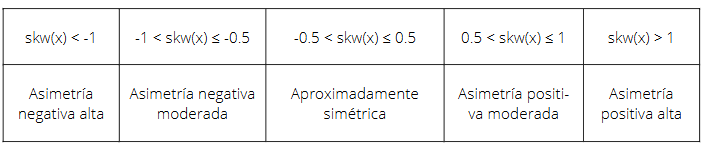


## Reajustar valores asimetricos en coeficientes de correlacion

Las asimetrias suelen suceder **por la existencia de valores que descuadran la relacion de valores entre variables** y comprometen el modelo de prediccion, ya que ponderan mas sus valores en la prediccion.

Por ello, es neecsario ejercer una transformacion en estos datos **a traves de una transformacion logaritmica, que reduce los valores grandes mas que los valores pequeños** e iguala los resultados, haciendo que sea mas simetrica.

Para ello aplicamos la funcion ***F.log1p()*** a los datos originales antes de realizar los calculos de coeficientes de correlacion de nuevo

> ***nombre variable.select(F.log1p("nombre columna 1 "), "nº de variables a correlacionar").alias("nombre nueva columna"),F.log1p("nombre columna 2 "), "nº de variables a correlacionar").alias("nombre nueva columna"),.... )***
>
> > De aquellas columnas que no queramos transformar datos, **simplemente las mencionamos, sin introducirlas en la formula**



## 2.0 Preparacion de los datos para usar algoritmos de machine learning: *pyspark.ml.VectorAssembler* y *VectorAssembler*

Una vez hemos entendido mejor como los datos dependen y se relacionan unos con otros, podemos empezar a trabajar en hipotesis de modelos que expliquen predigan su comportamiento con nuevos datos.

Aqui se aplica los algoritmos de Machine Learning.

El 1º paso en este proceso es **la preparacion de nuestros datos con los algoritmos** que requieren de unas caracteristicas en los datos para que funcione:

- Los datos de entrada (*inputCols*) tienen que tener la misma forma.
- Disponer de datos en una columna *para la variable a predecir*
- Disponer de al menos otra columna donde las variables explicativas se *empaquetan en vectores*

Importaremos la libreria ***pyspark.ml*** y haremos uso de varios metodos:

> ***from pyspark.ml.linalg import Vectors***
>
> ***from pyspark.ml.feature import VectorAssembler***


Lo que haremos es primero**generar valores vectorizados (*misma forma*) en base a unas columnas con datos** mediante el metodo ***VectorAssembler***, en segundo lugar mediante una transformacion **generar una nueva columna de estos datos vectorizados** y en tercer lugar **realizar un filtrado para escoger las columnas con variables explicativas**

> 1º Generamos los valores vectorizados
> 
>> ***"nombre ensamblador" = VectorAssembler(inputCols = ["nombre columna 1, "nombre columna 2",....], outputCol = "nombre columna vectores")***
>
> 2º Generamos la columna con los valores vectorizados
> 
>> ***"nombre dataframe nuevo" = "nombre ensamblador".transform("nombre dataframe original")***
>
> 3º Generamos un filtrado para coger columnas explicativas
> 
>> ***"nombre dataframe filtrado" = "nombre dataframe nuevo".where(col("nombre columna filtro") ==/>/<... condicion).select("columna vectores","nombre columa explicativa"...)***
>>
>> > Siempre hay que seleccionar: **la columna de los vectores** y **otra columna explicativa**

## 3.0 Division de datos de entrenamiento y test, para crear un modelo y ajustarlo con los datos de entrenamiento: *pyspark.ml.regression*, *LinearRegression* y *.fit()*

El siguiente paso es la creacion de un modelo de prediccion, que pueda entrenarse para mejorar su capacidad de prediccion.

Para ello, es necesario dotarle de **datos con los que pueda entrenarse y mejorar el ajuste del modelo** y otros datos con los que hacer una prueba real.

Hay que importar de la libreria el siguiente modulo **para poder crear el modelo de regresion linear**:

> ***from pyspark.ml.regression import LinearRegression***

Importamos *numpy* para poder **crear un dataframe de datos de entrenamiento.**

> ***import numpy as np***

Lo que haremos es primero **dividir el dataframe con datos** para obtener un dataframe con datos que pueda entrenar y otros para testear, en segundo lugar **generar un modelo con una recta de regresion** y por ultimo **ajustaremos este modelo con el dataframe de los datos de entrenamiento**

> 1º Generamos los dos dataframes con datos, entrenamiento y testeo
>
>> ***"nombre dataframe entrenamiento", "nombre dataframe testeo"  = "nombre dataframe filtrado".randomSplit([0.7,0.3])***
>
> 2º Creamos el modelo de regresion
> 
>> ***"nombre modelo" = LinearRegression(featuresCol = "nombre columna vectores", labelCol = "nombre columna explicativa")***
>>
>> > Es necesario indicar **el vector de variable explicativas (*featuresCol*) y cual es la columna objetivo (*labelCol*)**
>
> 3º Ajusta el modelo de regresion usando los datos de entrenamiento
> 
>> ***"nombre modelo ajustado" = "nombre modelo".fit("nombre dataframe entrenamiento")***

## 4.0 Utilizar el modelo de prediccion con los datos de test: *.transform()*

Una vez generado el modelo de prediccion y haberlo entrenado, podemos **realizar un test con el dataframe de datos de test** que nos ofrecera un resultado que posteriormente podremos evaluar, como paso final.

**Para realizar predicciones de un modelo creado, utilizamos *.transform()* la cual genera una columna llamada "prediction" con los valores predecidos**

> ***"nombre modelo predictivo" = "nombre modelo ajustado".transform("nombre dataframe testeo")***

## 5.0 Evaluar un modelo predictivo en base a sus resultados con los datos teste: *pyspark.ml.evaluation*, *RegressionEvaluator()* y *.evaluate()*

El ultimo paso es revisar **la calidad del modelo de prediccion**

Spark incluye varios métodos de evaluación y análisis de resultados de los modelos de machine learning en el módulo ***pyspark.ml.evaluation.***

> ***from pyspark.ml.evaluation import RegressionEvaluator***

Realizaremos una **evaluacion de los resultados de la regresion obtenidos tras usar los datos de testeo** que nos dara como resultado **una metrica de evaluacion**, finalmente podemos **evaluar esa metrica con los datos con la prediccion**

> 1º Evaluamos el modelo:
>
>> ***"nombre evaluador" = RegressionEvaluator(predictionCol ="prediction", labelCol = "nombre columna valores reales", metricName = "metrica de evaluacion")***
>
> >>  Debemos indicarle cuál es la columna con el valor estimado por el modelo *(predictionCol)*, la columna con el valor real *(labelCol)* y qué métrica queremos calcular para evaluar los resultados *(metricName)*
> >>
> >> Generalmente en el metricName se indica ***rmse*** (**error cuadratico medio***)
> 
> 2º Evaluamos la metrica en los resultados predecidos
> 
>> ***"nombre evaluador".evaluate("nombre modelo predictivo")***

## 6.0 Construyendo modelos de Clasificacion: *pyspark.ml.classification* y *LogisticRegression*

La otra utilidad mas extendida de las capacidades y arquitecturas de la libreria de Machine Learning **es la construccion de modelos de clasificacion, que nos ayudan a detectar si una entidad es de un tipo u otro en base a unas caracteristicas medibles.**

Para ello la libreria incluye la capacidad de crear modelos en base a **regresiones logisticas** a traves de su libreria ***pyspark.ml.classification***

> ***from pyspark.ml.classification import LogisticRegression***

Lo que haremos es realizar un ejercicio similar al anterior:

- 1º Generamos valores vectorizados de los datos, en una columna de un dataframe nuevo
- 2º **Asignamos un valor numerico a cada indice de las categorias, ya que es necesario para el modelo se ejecute**
- 3º Seleccionamos las columnas que sirven para categorizar, el indice y la columna con los valores vectorizados.
- 4º Dividimos los datos en un dataframe de entrenamiento y otro de testeo
- 5º Creamos un modelo y lo ajustamos
- 6º Aplicamos el modelo ajustado a los datos de test

### 1º Crear los valores vectorizados y crear una columna en el dataframe original 

> ***"nombre ensamblador" = VectorAssembler(inputsCols = ["nombre columna 1, "nombre columna 2",....], outputCol = "nombre columna vectores")***
>
> ***"nombre dataframe nuevo" = "nombre ensamblador".transform("nombre dataframe original")***

### 2º Asignamos valores numericos a los indices de la columna que sirve para categorizar: *StringIndexer*

> ***"nombre indice" = StringIndexer(inputsCols = "nombre columna de categorias", outputCol = "nuevo nombre columna con valores numericos de categorias")***

### 3º Seleccionamos las columnas para 1º categorizar, 2º Indice, 3º con valores vectorizados.

> ***"nombre indice seleccionado" = "nombre indice".select("nombre columna categorizar", "nombre columna con valores numericos de categorias", "nombre columna vectores")***

### 4º Dividimos el dataframe original en 2 dataframes: uno de entrenamiento y otro de testeo.

> ***"nombre dataframe entrenamiento", "nombre dataframe testeo" = "nombre dataframe filtrado".randomSplit([0.7,0.3])***

### 5º Creamos el modelo y lo ajustamos con los datos de entrenamiento

> ***"nombre modelo" = LogisticRegression(featuresCol = "nombre columna categorizar", labelCol = "nombre columna con valores numericos de categorias", fitIntercept = True)***
>
> ***"nombre modelo ajustado" = "nombre modelo".fit("nombre dataframe entrenamiento")***

### 6º Probamos el modelo ajustado con los datos de test

> ***"nombre modelo predictivo" = "nombre modelo ajustado".transform("nombre dataframe testeo")***

### 6.1 Evaluar el modelo de clasificacion: *AUC-ROC*

**Es un sistema metrico para modelos de clasificacion que te indica en un valor entre 0 y 1 la calidad del clasificador**

> **VIP: Se utiliza solo entre 2 clases o categorias**

Se entienden asi los valores:

- **AUC = 0.5 (La línea diagonal):** Tu modelo es aleatorio. Es igual de efectivo que lanzar una moneda al aire. No ha aprendido nada.
- **AUC = 1.0 (El cuadrado perfecto):** Tu modelo es perfecto. Distingue el 100% de los casos sin cometer ni un solo error. (Sospecha si ves esto, suele ser overfitting).
- **AUC = 0.7 - 0.8:** Aceptable.
- **AUC > 0.8:** Muy bueno.

Para ello utilizaremos la libreria ***pyspark.ml.evaluation*** y su modulo ***BinaryClassifcationEvaluator***

> ***from pyspark.ml.evaluation import BinaryClassificationEvaluator***
>
> ***"nombre modelo evaluado" = BinaryClassificationEvaluator(rawPredictionCol = "prediction", labelCol = "nombre columna con valores numericos de categorias", metricName = "areaUnderROC")***